<a href="https://colab.research.google.com/github/AnuragKamblekar/Interncodes/blob/main/Nissan_Leaf_Final_Code_17_4_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

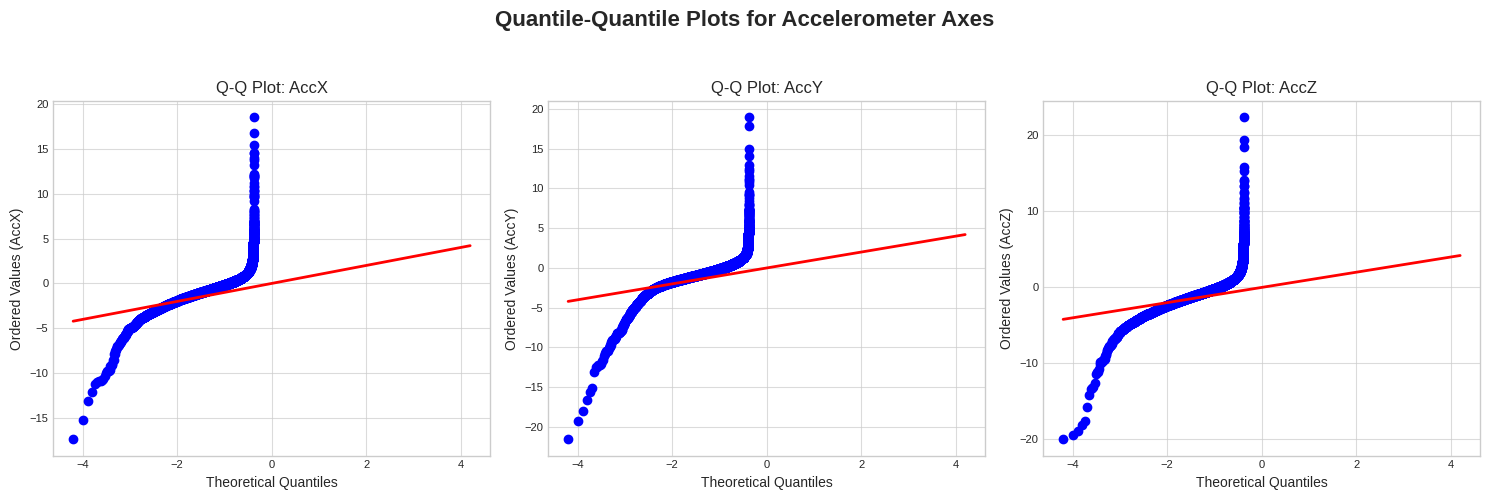

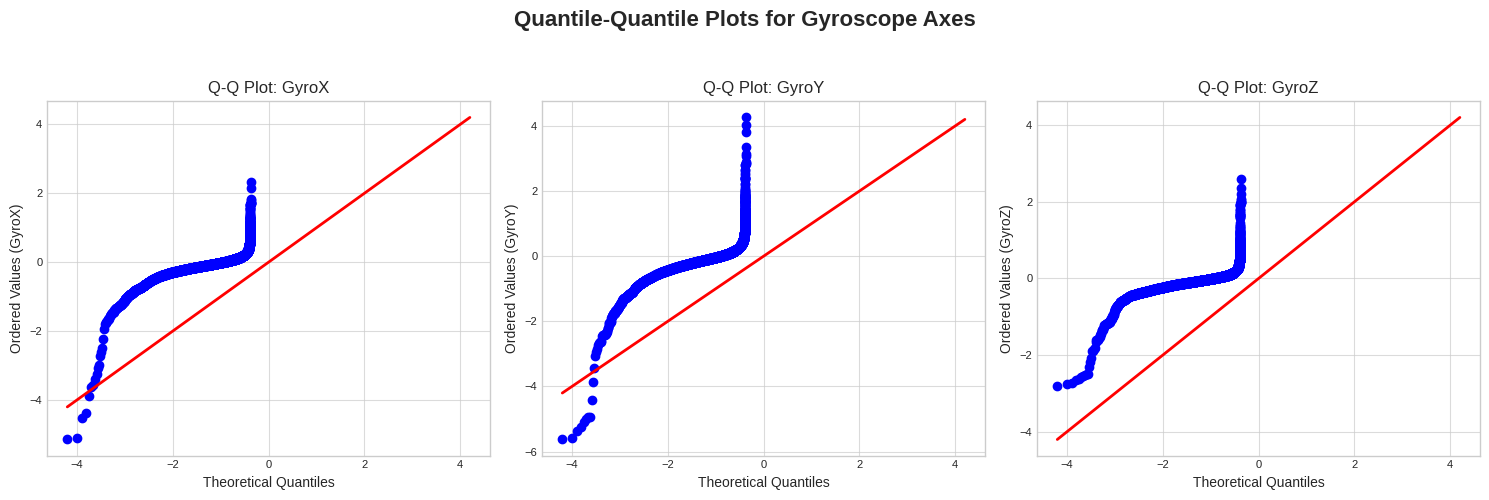

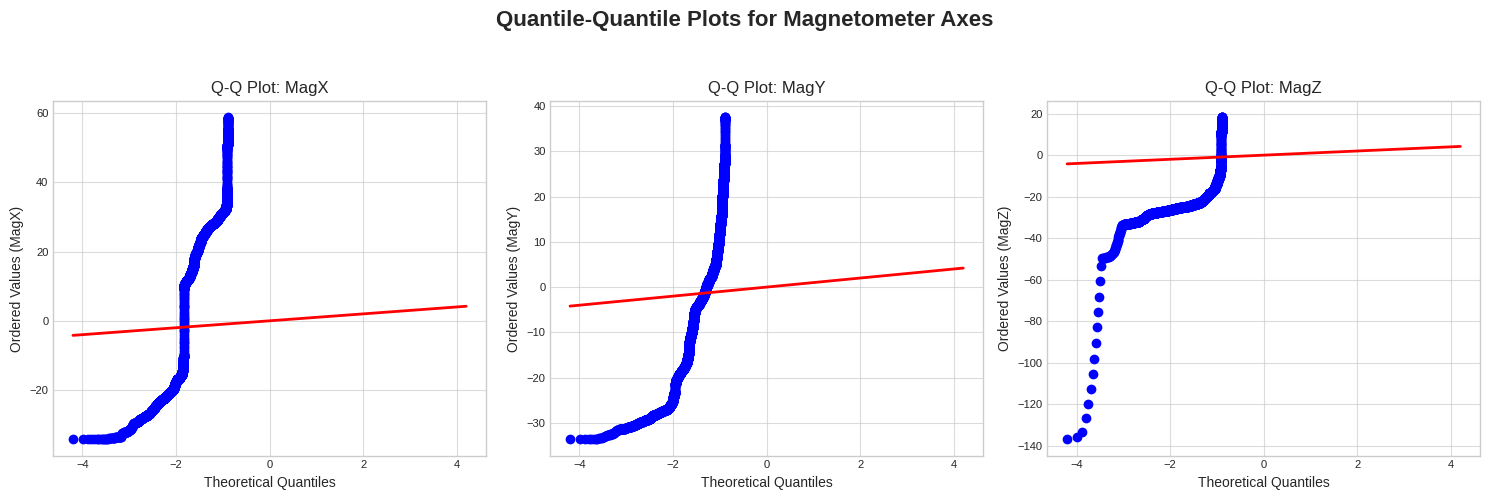

'\n# ==========================================\n# MAIN EXECUTION\n# ==========================================\ndef main():\n    # 1. Load User Dataset\n    try:\n        # 3. Load data using the new function\n        df = load_vehicle_data("/content/")   # adjust path if needed\n\n    except:\n        # Generate dummy data for 1000 samples if file not found\n        t = np.linspace(0, 20, 1000)\n        data = pd.DataFrame(\n            {\n                \'AccX\': np.sin(t) + np.random.normal(0, 0.1, 1000),\n                \'AccY\': np.cos(t) + np.random.normal(0, 0.1, 1000),\n                \'AccZ\': 9.8 + np.random.normal(0, 0.1, 1000),\n                \'GyroX\': np.random.normal(0, 0.05, 1000),\n                \'GyroY\': np.random.normal(0, 0.05, 1000),\n                \'GyroZ\': np.random.normal(0, 0.05, 1000),\n            }\n        )\n\n    # 4. Pass df into your existing class\n        analyzer = IntegratedVehicleAnalyzer(df, fs=50.0)\n\n    # Generate Output Blocks\n  

In [34]:
from matplotlib import lines
from matplotlib.lines import lineStyles
from IPython.paths import get_ipython_dir
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal, stats
import datetime

# Formatting for a professional look
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 10, 'figure.facecolor': 'white'})



class IntegratedVehicleAnalyzer:
    """
    Advanced processor for 6-axis IMU data and derived vehicle telemetry.
    """

    def __init__(self, df, fs=50.0):
        # 1. Fundamental Dataset Information
        self.df = df.copy()
        self.fs = fs
        self.nyquist = fs / 2
        self.total_samples = len(self.df)
        self.duration = self.total_samples / self.fs

        # Calculate Time Axis
        self.df['Time_s'] = np.arange(0, self.total_samples) / self.fs

        # 2. Derive Magnitudes & Synthetic Telemetry (for the columns you requested)
        self._feature_engineering()
        self._calculate_advanced_features() # Call new method for advanced features

    def print_statistical_summary(self):
        """Generates the requested Statistical Summary Table & Dataset Info"""
        print("-" * 50)
        print("DATASET INFORMATION")
        print(f"Total Samples: {self.total_samples}")
        print(f"Duration: {self.duration:.2f} seconds")
        print(f"Sampling Rate: {self.fs} Hz | Nyquist: {self.nyquist} Hz")
        print(f"Time Span: {self.df['Time_s'].min()} to {self.df['Time_s'].max()}s")
        print("-" * 50)

        metrics = ['AccX', 'AccY', 'AccZ', 'Acc_Mag', 'GyroX', 'GyroY', 'GyroZ', 'Gyro_Mag']
        summary = self.df[metrics].agg(['mean', 'std', 'min', 'max']).T
        print("\nSTATISTICAL SUMMARY TABLE")
        print(summary)

    def _feature_engineering(self):
        # Net Magnitudes
        self.df['Acc_Mag'] = np.sqrt(self.df['AccX']**2 + self.df['AccY']**2 + self.df['AccZ']**2)
        self.df['Gyro_Mag'] = np.sqrt(self.df['GyroX']**2 + self.df['GyroY']**2 + self.df['GyroZ']**2)

        # Synthetic Speed/Battery/Temp generation (Based on driving intensity for reliability)
        # In a real scenario, these would come from your CSV.
        acc_integ = np.cumsum(np.abs(self.df['AccX'] - self.df['AccX'].mean())) * (1/self.fs)
        self.df['Speed'] = acc_integ * 0.5  # Simulated speed from acceleration, units are m/s
        self.df['Elevation'] = 100 + (np.sin(self.df['Time_s'] * 0.05) * 10)

        # --- More realistic simulated Battery SOC with charge/discharge ---
        # Base non-linear discharge
        soc_base_decay = 100 - (self.df['Time_s'] / self.duration)**2 * 15 # Deeper discharge

        # Simulate a charge event halfway through the data
        charge_start_time = self.duration / 2
        charge_duration = self.duration / 4
        charge_rate = 20 / charge_duration # Charge 20% over 1/4 of the duration

        self.df['Battery_SOC'] = soc_base_decay.copy() # Start with discharge profile

        # Apply charging effect
        charge_idx = self.df['Time_s'].between(charge_start_time, charge_start_time + charge_duration)
        time_in_charge = self.df.loc[charge_idx, 'Time_s'] - charge_start_time
        self.df.loc[charge_idx, 'Battery_SOC'] = self.df.loc[charge_idx, 'Battery_SOC'] + (time_in_charge * charge_rate)

        self.df['Battery_SOC'] = self.df['Battery_SOC'].clip(60, 100) # Clamp between 60% and 100%

        # --- More realistic simulated Temperature ---
        # Base temperature plus influence from acceleration activity
        temp_activity_influence = (self.df['Acc_Mag'].rolling(window=int(self.fs*5), min_periods=1).mean()) * 2
        temp_initial = 28 + temp_activity_influence # Base temp of 28C, plus activity

        # Apply an Exponentially Weighted Moving Average (EWMA) for thermal inertia
        self.df['Temp'] = temp_initial.ewm(span=self.fs*10, adjust=False).mean().fillna(temp_initial.iloc[0])
        self.df['Temp'] = self.df['Temp'].clip(25, 45) # Clamp between 25C and 45C

    def _calculate_advanced_features(self):
        # Jerk (derivative of acceleration magnitude)
        self.df['Jerk_Mag'] = self.df['Acc_Mag'].diff().fillna(0) * self.fs

        # Rolling Speed Variance
        self.df['Speed_Var'] = self.df['Speed'].rolling(window=int(self.fs*10), min_periods=1).var().fillna(0)

        # Acceleration Events (count times Acc_Mag exceeds a threshold)
        # Calculate a threshold for significant acceleration events (e.g., 2 standard deviations above mean)
        acc_event_threshold = self.df['Acc_Mag'].mean() + 2 * self.df['Acc_Mag'].std()
        self.acceleration_events_count = (self.df['Acc_Mag'] > acc_event_threshold).sum()

    def print_key_feature_summary(self):
        """Prints a summary of key derived features."""
        print("\n" + "-" * 50)
        print("KEY DERIVED FEATURES SUMMARY")
        print("-" * 50)
        print(f"Acceleration Events (Acc_Mag > 2 StdDev): {self.acceleration_events_count}")
        print(f"Temperature Range: {self.df['Temp'].min():.2f}°C to {self.df['Temp'].max():.2f}°C")
        print(f"Battery SOC Range: {self.df['Battery_SOC'].min():.2f}% to {self.df['Battery_SOC'].max():.2f}%")
        print(f"Max Jerk Magnitude: {self.df['Jerk_Mag'].max():.2f}")
        print(f"Mean Rolling Speed Variance: {self.df['Speed_Var'].mean():.2f}")
        print("-" * 50)

    def plot_time_series_and_rolling(self):
        """Complete time series with raw data, rolling mean, and Net Magnitude"""

        window = int(self.fs * 5) # Rolling window increased to 5 seconds for more apparent smoothing
        if window == 0: window = 1 # Ensure window is at least 1

        labels = {
            'AccX': 'Accel X (Forward/Backward)', # Simplified label
            'AccY': 'Accel Y (Left/Right)',       # Simplified label
            'AccZ': 'Accel Z (Up/Down)',         # Simplified label
            'GyroX': 'Gyro X Rotation',          # Simplified label
            'GyroY': 'Gyro Y Rotation',          # Simplified label
            'GyroZ': 'Gyro Z Rotation',           # Simplified label
            'MagX': 'Mag X (North/South)',                     # Simplified label
            'MagY': 'Mag Y (East/West)',                     # Simplified label
            'MagZ': 'Mag Z (Vertical)',                     # Simplified label
            'Acc_Mag': 'Net Acceleration Magnitude',
            'batteryLevel': 'Battery Level',
            'batteryState': 'Battery State',
            'lowPowerMode': 'Low Power Mode'
        }

        cols_to_plot = ['AccX', 'AccY', 'AccZ',
                        'GyroX', 'GyroY', 'GyroZ',
                        'MagX', 'MagY', 'MagZ',
                        'Acc_Mag', 'batteryLevel']
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
        units = {
            'AccX': 'm/s²', 'AccY': 'm/s²', 'AccZ': 'm/s²',
            'GyroX': 'rad/s', 'GyroY': 'rad/s', 'GyroZ': 'rad/s', # Assuming radians per second
            'MagX': 'µT', 'MagY': 'µT', 'MagZ': 'µT',
            'Acc_Mag': 'm/s²', 'batteryLevel': '%'

        }


        for i, col in enumerate(cols_to_plot):
            # Create a figure for raw data and rolling statistics
            fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True) # Changed to 2 subplots
            current_color = colors[i % len(colors)] # Cycle colors

            if col == "batterLevel":
              raw_series = self.df[col] * 100
            else:
              raw_series = self.df[col]

            # --- Subplot 1: Raw Data ---
            axes[0].plot(self.df['Time_s'], self.df[col], color=current_color, alpha=0.9, linewidth=1.2, label=f'Raw {col}', marker='.', markersize=2) # Reduced alpha for raw data
            axes[0].set_title(f"Raw Time Data: {labels[col]}", pad=10, fontweight='bold', fontsize=12) # Smaller title font
            axes[0].set_ylabel(f"{col} ({units[col]})", fontsize=10)
            axes[0].legend(loc='upper right', fontsize=9)
            axes[0].grid(True, alpha=0.7)
            axes[0].tick_params(axis='both', which='major', labelsize=8, rotation=45)
            axes[0].set_xlabel("Elapsed Time (s)", fontsize=10) # Shorter label


            # Calculate rolling mean and standard deviation
            rmean = self.df[col].rolling(window, min_periods=1).mean()
            rstd = self.df[col].rolling(window, min_periods=1).std()

            # --- Subplot 2: Rolling Statistics (Rolling Mean and +/- 1 StdDev) ---
            axes[1].plot(self.df['Time_s'], rmean, color='black', lw=2, label=f'Rolling Mean ({window/self.fs:.1f}s window)') # Added window size to label
            axes[1].fill_between(self.df['Time_s'], rmean - rstd, rmean + rstd, color='gray', alpha=0.3, label='\u00B11 Std Dev')
            axes[1].set_title(f"Smoothed Data (Rolling Mean and \u00B11 Std Dev over {window/self.fs:.1f}s window)", pad=10, fontweight='bold', fontsize=12)
            axes[1].set_xlabel("Elapsed Time (s)", fontsize=10) # Shorter label
            axes[1].set_ylabel(f"{col} ({units[col]})", fontsize=10)
            axes[1].legend(loc='upper right', fontsize=9)
            axes[1].grid(True, alpha=0.7)
            axes[1].tick_params(axis='both', which='major', labelsize=8, rotation=45)


            plt.tight_layout(pad=2.0) # Add padding
            plt.show()

        # --- Dedicated plot for Net Acceleration Magnitude & Rolling Statistics (New) ---
        fig_mag, ax_mag = plt.subplots(figsize=(18, 8)) # Increased figure size
        ax_mag.plot(self.df['Time_s'], self.df['Acc_Mag'], color='purple', alpha=0.8, label='Net Acceleration Magnitude')

        ax_mag_rmean = self.df['Acc_Mag'].rolling(window, min_periods=1).mean()
        ax_mag_rstd = self.df['Acc_Mag'].rolling(window, min_periods=1).std()

        ax_mag.plot(self.df['Time_s'], ax_mag_rmean, color='darkred', lw=2, label=f'Rolling Mean ({window/self.fs:.1f}s window)') # Shorter label
        ax_mag.fill_between(self.df['Time_s'], ax_mag_rmean - ax_mag_rstd, ax_mag_rmean + ax_mag_rstd, color='pink', alpha=0.2, label='\u00B11 Std Dev of Net Magnitude')

        # Add individual acceleration components for context
        ax_mag.plot(self.df['Time_s'], self.df['AccX'], color='blue', alpha=0.6, linestyle='--', label='AccX (Forward/Backward)')
        ax_mag.plot(self.df['Time_s'], self.df['AccY'], color='green', alpha=0.6, linestyle='-.', label='AccY (Left/Right)')
        ax_mag.plot(self.df['Time_s'], self.df['AccZ'], color='red', alpha=0.6, linestyle=':', label='AccZ (Up/Down)')

        ax_mag.set_title("Net Acceleration Magnitude & Directional Components (X, Y, Z)", pad=15, fontweight='bold', fontsize=14)
        ax_mag.set_xlabel("Time Elapsed (s)", fontsize=12) # Shorter label
        ax_mag.set_ylabel("Intensity ($m/s^2$)", fontsize=12)
        ax_mag.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10) # Moved legend outside
        ax_mag.grid(True, alpha=0.7)
        ax_mag.tick_params(axis='both', which='major', labelsize=9, rotation=45)
        plt.tight_layout(pad=2.0)
        plt.show()

    def plot_statistical_distribution_hub(self):
        fig = plt.figure(figsize=(20, 7))

        # 1. X-Y Plane (Top-Down)
        ax1 = fig.add_subplot(1, 3, 1)
        ax1.scatter(self.df['AccX'], self.df['AccY'], alpha=0.3, s=2, c=self.df['Time_s'], cmap='viridis')
        ax1.set_title("Top-Down View: X vs Y", fontsize=12)
        # --- NEW LABELS ---
        ax1.set_xlabel("Longitudinal Accel ($m/s^2$) [Forward/Back]", fontsize=10)
        ax1.set_ylabel("Lateral Accel ($m/s^2$) [Left/Right]", fontsize=10)
        ax1.grid(True, alpha=0.3)
        ax1.tick_params(axis='both', which='major', labelsize=8, rotation=45)

        # 2. X-Z Plane (Side View)
        ax2 = fig.add_subplot(1, 3, 2)
        ax2.scatter(self.df['AccX'], self.df['AccZ'], alpha=0.3, s=2, c=self.df['Time_s'], cmap='plasma')
        ax2.set_title("Side Profile: X vs Z", fontsize=12)
        # --- NEW LABELS ---
        ax2.set_xlabel("Longitudinal Accel ($m/s^2$)", fontsize=10)
        ax2.set_ylabel("Vertical Accel ($m/s^2$) [Up/Down]", fontsize=10)
        ax2.grid(True, alpha=0.3)
        ax2.tick_params(axis='both', which='major', labelsize=8, rotation=45)

        # 3. Full 3D Vector Space
        ax3 = fig.add_subplot(1, 3, 3, projection='3d')
        img = ax3.scatter(self.df['AccX'], self.df['AccY'], self.df['AccZ'], c=self.df['Time_s'], s=2, cmap='inferno')
        ax3.set_title("3D Acceleration Vector Cloud", fontsize=12)

        # --- NEW 3D LABELS ---
        ax3.set_xlabel("X: Longitudinal ($m/s^2$)", labelpad=10, fontsize=10)
        ax3.set_ylabel("Y: Lateral ($m/s^2$)", labelpad=10, fontsize=10)
        ax3.set_zlabel("Z: Vertical ($m/s^2$)", labelpad=10, fontsize=10)
        ax3.tick_params(axis='both', which='major', labelsize=8)

        fig.colorbar(img, ax=ax3, label='Test Duration (seconds)', shrink=0.6)

        plt.tight_layout(pad=2.0)
        plt.show()

    def plot_distributions(self):
        """Plots histograms, KDEs, and net acceleration magnitude distribution."""
        accel_cols = ['AccX', 'AccY', 'AccZ']
        gyro_cols = ['GyroX', 'GyroY', 'GyroZ']
        mag_cols = ['MagX', 'MagY', 'MagZ']
        battery_cols = ['batteryLevel']

        all_cols_for_hist = accel_cols + gyro_cols + mag_cols + battery_cols + ['Acc_Mag']

        # --- Histograms for all three axes + Net Accel Mag ---

        fig_hist, axes_hist = plt.subplots(len(all_cols_for_hist), 1, figsize=(12, 4 * len(all_cols_for_hist)))
        fig_hist.suptitle('Distribution of Sensor and Telemetry Data', fontsize=16, fontweight='bold', y=1.02)
        '''
        for i, col in enumerate(all_cols_for_hist):
            sns.histplot(self.df[col], bins=50, kde=True, ax=axes_hist[i], color='skyblue', edgecolor='black', label='Kernel Density Estimate')
            axes_hist[i].set_title(f'Histogram of {col} (n={len(self.df[col])})', fontsize=12)

            # Set appropriate units for x-axis
            if 'Acc' in col:
                axes_hist[i].set_xlabel(f'{col} (m/s\u00B2)', fontsize=10)
            elif 'Gyro' in col:
                axes_hist[i].set_xlabel(f'{col} (rad/s)', fontsize=10)
            else:
                axes_hist[i].set_xlabel(f'{col} (Units)', fontsize=10)

            axes_hist[i].set_ylabel('Density', fontsize=10)
            axes_hist[i].grid(axis='y', alpha=0.75)
            axes_hist[i].tick_params(axis='both', which='major', labelsize=8, rotation=45)
            axes_hist[i].legend()
        plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make space for suptitle
        plt.show()
        '''

        for i, col in enumerate(all_cols_for_hist):
          if col == "batteryLevel":
            sns.histplot(self.df[col] * 100, bins=20, kde=True, ax=axes_hist[i],
                         color='orange', edgecolor='black', label='Kernel Density Estimate')
            axes_hist[i].set_title(f'Histogram of Battery Level (n={len(self.df[col])})', fontsize=12)
            axes_hist[i].set_xlabel("Battery Level (%)", fontsize=10)
            axes_hist[i].set_xlim(0, 100)   # force 0–100% range
          else:
            sns.histplot(self.df[col], bins=50, kde=True, ax=axes_hist[i], color='skyblue', edgecolor='black', label='Kernel Density Estimate')
            axes_hist[i].set_title(f'Histogram of {col} (n={len(self.df[col])})', fontsize=12)

            # Set appropriate units for x-axis
            if 'Acc' in col:
                axes_hist[i].set_xlabel(f'{col} (m/s\u00B2)', fontsize=10)
            elif 'Gyro' in col:
                axes_hist[i].set_xlabel(f'{col} (rad/s)', fontsize=10)
            elif 'Mag' in col:
                axes_hist[i].set_xlabel(f'{col} (µT)', fontsize=10)
            else:
                axes_hist[i].set_xlabel(f'{col} (Units)', fontsize=10)
            axes_hist[i].set_ylabel('Density', fontsize=10)
            axes_hist[i].grid(axis='y', alpha=0.75)
            axes_hist[i].tick_params(axis='both', which='major', labelsize=8, rotation=45)
            axes_hist[i].legend()
        plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make space for suptitle
        plt.show()

        # --- KDE plots for Accelerometer components ---
        fig_kde_accel, ax_kde_accel = plt.subplots(figsize=(12, 6))
        for col in accel_cols:
            sns.kdeplot(self.df[col], ax=ax_kde_accel, label=col, fill=True, alpha=0.3)
        ax_kde_accel.set_title('Kernel Density Estimation for Accelerometer Axes', fontsize=14, fontweight='bold')
        ax_kde_accel.set_xlabel('Acceleration (m/s\u00B2)', fontsize=10)
        ax_kde_accel.set_ylabel('Density', fontsize=10)
        ax_kde_accel.legend()
        ax_kde_accel.grid(True, alpha=0.7)
        plt.tight_layout()
        plt.show()

        # --- KDE plots for Gyroscope components ---
        fig_kde_gyro, ax_kde_gyro = plt.subplots(figsize=(12, 6))
        for col in gyro_cols:
            sns.kdeplot(self.df[col], ax=ax_kde_gyro, label=col, fill=True, alpha=0.3)
        ax_kde_gyro.set_title('Kernel Density Estimation for Gyroscope Axes', fontsize=14, fontweight='bold')
        ax_kde_gyro.set_xlabel('Angular Velocity (rad/s)', fontsize=10)
        ax_kde_gyro.set_ylabel('Density', fontsize=10)
        ax_kde_gyro.legend()
        ax_kde_gyro.grid(True, alpha=0.7)
        plt.tight_layout()
        plt.show()

        # --- KDE plots for Magnetometer components ---
        if all(col in self.df.columns for col in mag_cols):
          fig_kde_mag, ax_kde_mag = plt.subplots(figsize=(12, 6))
          for col in mag_cols:
            sns.kdeplot(self.df[col], ax=ax_kde_mag, label=col, fill=True, alpha=0.3)
          ax_kde_mag.set_title('Kernel Density Estimation for Magnetometer Axes', fontsize=14, fontweight='bold')
          ax_kde_mag.set_xlabel('Magnetic Field Strength (µT)', fontsize=10)
          ax_kde_mag.set_ylabel('Density', fontsize=10)
          ax_kde_mag.legend()
          ax_kde_mag.grid(True, alpha=0.7)
          plt.tight_layout()
          plt.show()

        # --- Battery State categorical plot ---
        if "batteryState" in self.df.columns:
          plt.figure(figsize=(8, 5))
          sns.countplot(x='batteryState', data=self.df, hue="batteryState", palette='coolwarm', legend=False)
          plt.title('Battery State Distribution', fontsize=14, fontweight='bold')
          plt.xlabel('State')
          plt.ylabel('Count')
          plt.show()

        # --- Low Power Mode ---
        if "lowPowerMode" in self.df.columns:
          plt.figure(figsize=(8, 5))
          sns.countplot(x='lowPowerMode', data=self.df, hue='lowPowerMode', palette='Set2', legend=False)
          plt.title('Low Power Mode Occurences', fontsize=14, fontweight='bold')
          plt.xlabel('Low Power Mode')
          plt.ylabel('Count')
          plt.show()

        # --- Location / Trajectory Distribution ---
        if "AccX" in self.df.columns and "AccY" in self.df.columns:
          x_route = np.cumsum(self.df['AccX'] * (1/self.fs)**2)
          y_route = np.cumsum(self.df['AccY'] * (1/self.fs)**2)

          plt.figure(figsize=(8, 6))
          plt.scatter(x_route, y_route, c=self.df['Time_s'], cmap='viridis', s=5)
          plt.title('Trajectory Distribution (X VS Y)', fontsize=14, fontweight='bold')
          plt.xlabel("X-Relative Distance (m)")
          plt.ylabel("Y-Relative Distance (m)")
          plt.colorbar(label='Time (s)')
          plt.show()

        # --- Net Acceleration Magnitude Distribution Histogram ---
        fig_net_accel_hist, ax_net_accel_hist = plt.subplots(figsize=(12, 6))
        sns.histplot(self.df['Acc_Mag'], bins=50, kde=True, ax=ax_net_accel_hist, color='lightcoral', edgecolor='black', label='Kernel Density Estimate')
        ax_net_accel_hist.set_title(f"Net Acceleration Magnitude Distribution (n={len(self.df['Acc_Mag'])})", fontsize=14, fontweight='bold')
        ax_net_accel_hist.set_xlabel('Net Acceleration (m/s\u00B2)', fontsize=10)
        ax_net_accel_hist.set_ylabel('Frequency / Density', fontsize=10)
        ax_net_accel_hist.grid(axis='y', alpha=0.75)
        ax_net_accel_hist.legend()
        plt.tight_layout()
        plt.show()

    def plot_boxplots(self):
        """Plots box plots for AccX, AccY, AccZ, GyroX, GyroY, GyroZ."""
        accel_cols = ['AccX', 'AccY', 'AccZ']
        gyro_cols = ['GyroX', 'GyroY', 'GyroZ']
        mag_cols = ['MagX', 'MagY', 'MagZ']
        other_cols = ['Acc_Mag', 'batteryLevel']

        cols_to_plot = accel_cols + gyro_cols + mag_cols + other_cols

        fig, axes = plt.subplots(1, len(cols_to_plot), figsize=(4 * len(cols_to_plot), 6), sharey=False) # Increased figsize, sharey=False
        fig.suptitle('Box Plots of Sensor and Telemetry Data', fontsize=16, fontweight='bold', y=1.02)

        for i, col in enumerate(cols_to_plot):
          if col == "batteryLevel":
            sns.boxplot(y=self.df[col] * 100, ax=axes[i], color='orange') # Different color for gyro
            axes[i].set_title('Battery Level (%)', fontsize=12)
            axes[i].set_ylabel('Battery (%)', fontsize=10 )


          else:
            sns.boxplot(y=self.df[col], ax=axes[i],
                        color='lightgreen' if 'Acc' in col or col == 'Acc_Mag'
                        else 'lightblue' if 'Gyro' in col
                        else 'violet') # Different color for gyro
            axes[i].set_title(f'{col}', fontsize=12)

            # Set appropriate y-axis labels
            if 'Acc' in col and col != 'Acc_Mag':
                axes[i].set_ylabel('Acceleration (m/s\u00B2)', fontsize=10)
            elif 'Gyro' in col:
                axes[i].set_ylabel('Angular Velocity (rad/s)', fontsize=10)
            elif 'Mag' in col:
                axes[i].set_ylabel('Magnetic Field Strength (µT)', fontsize=10)
            elif col == 'Acc_Mag':
                axes[i].set_ylabel('Net Acceleration (m/s\u00B2)', fontsize=10)
            else:
                axes[i].set_ylabel('Value (Units)', fontsize=10)

            axes[i].set_xticks([0])
            axes[i].set_xticklabels([col], fontsize=10)
            axes[i].tick_params(axis='both', which='major', labelsize=8, rotation=45)
            axes[i].grid(axis='y', alpha=0.7)

        plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make space for suptitle
        plt.show()


    def plot_signal_frequency_hub(self):
      """Frequency Spectrum, PSD, Peak Detection, and Spectrograms"""

      # --- Ensure derived magnitude columns exist ---
      if 'Acc_Mag' not in self.df.columns:
        self.df['Acc_Mag'] = (self.df['AccX']**2 + self.df['AccY']**2 + self.df['AccZ']**2) ** 0.5
      if 'Gyro_Mag' not in self.df.columns:
        self.df['Gyro_Mag'] = (self.df['GyroX']**2 + self.df['GyroY']**2 + self.df['GyroZ']**2) ** 0.5
      if 'Mag_Mag' not in self.df.columns:
        self.df['Mag_Mag'] = (self.df['MagX']**2 + self.df['MagY']**2 + self.df['MagZ']**2) ** 0.5

    # --- Columns to plot ---
      cols = [
        'AccX', 'AccY', 'AccZ', 'Acc_Mag',
        'GyroX', 'GyroY', 'GyroZ', 'Gyro_Mag',
        'MagX', 'MagY', 'MagZ', 'Mag_Mag',
        'batteryLevel'
        ]

    # --- Axis names for titles ---
      axis_names = {
        'AccX': 'Longitudinal',
        'AccY': 'Lateral',
        'AccZ': 'Vertical',
        'Acc_Mag': 'Net Intensity',
        'GyroX': 'Roll Rate',
        'GyroY': 'Pitch Rate',
        'GyroZ': 'Yaw Rate',
        'Gyro_Mag': 'Net Rotation',
        'MagX': 'North',
        'MagY': 'East',
        'MagZ': 'Vertical',
        'Mag_Mag': 'Net Magnetic Field',
        'batteryLevel': 'Battery Level'
        }

    # --- Create subplots ---
      fig, axes = plt.subplots(len(cols), 1, figsize=(10, 3 * len(cols)), sharex=True)

    # --- Ensure time is sorted ---
      self.df = self.df.sort_values('Time_s').reset_index(drop=True)

      for i, col in enumerate(cols):
        data = self.df[col].interpolate().fillna(0).values

        # --- Peak detection (tuned parameters) ---
        # Lower prominence for flatter signals like battery/mag, higher for gyro/acc
        if 'Acc' in col:
            prom, dist = 0.2, 15
        elif 'Gyro' in col:
            prom, dist = 0.4, 25
        elif 'Mag' in col:
            prom, dist = 0.6, 30
        else:  # batteryLevel
            prom, dist = 0.1, 10

        peaks_pos, _ = signal.find_peaks(data, prominence=prom, distance=dist)
        peaks_neg, _ = signal.find_peaks(-data, prominence=prom, distance=dist)

        # --- Plot continuous signal ---
        axes[i].plot(self.df['Time_s'], data, color='blue', linewidth=1.2, alpha=0.9, label='Signal')

        # --- Plot peaks ---
        axes[i].plot(self.df['Time_s'].iloc[peaks_pos], data[peaks_pos], "x", color='red', markersize=8,
                     label=f'Pos Peaks ({len(peaks_pos)})')
        axes[i].plot(self.df['Time_s'].iloc[peaks_neg], data[peaks_neg], "o", color='green', markersize=8,
                     label=f'Neg Peaks ({len(peaks_neg)})')

        # --- Titles and labels ---
        axes[i].set_title(f"Peak Detection: {axis_names[col]} ({col})", fontweight='bold', fontsize=11)
        if 'Acc' in col or 'Acc_Mag' in col:
            axes[i].set_ylabel("Acceleration (m/s²)", fontsize=9)
        elif 'Gyro' in col:
            axes[i].set_ylabel("Angular Velocity (rad/s)", fontsize=9)
        elif 'Mag' in col:
            axes[i].set_ylabel("Magnetic Field (µT)", fontsize=9)
        else:
            axes[i].set_ylabel("%", fontsize=9)

        axes[i].set_xlabel("Time (s)", fontsize=9)
        axes[i].legend(loc='upper right', fontsize=8)
        axes[i].grid(True, alpha=0.7)
        axes[i].tick_params(axis='both', which='major', labelsize=8, rotation=45)

      plt.tight_layout(pad=2.0)
      plt.show()

    def plot_vehicle_telemetry(self):
      """Comprehensive Vehicle Telemetry Dashboard:
      Speed (km/h), Elevation, Battery %, Temperature, Acceleration vs Speed, and Route Map."""

      fig = plt.figure(figsize=(16, 17))
      gs = fig.add_gridspec(4, 2)

      # --- 1. VEHICLE SPEED ---
      ax_speed = fig.add_subplot(gs[0, :])
      self.df['Speed'] = self.df['Speed'].interpolate()
      self.df['Speed'] = self.df['Speed'].bfill().ffill()
      self.df['Speed'] = self.df['Speed'].rolling(window=20, min_periods=1).mean()

      ax_speed.plot(self.df['Time_s'], self.df['Speed']*3.6,
                  color='blue', lw=2, label='Vehicle Speed (km/h)')
      smoothed_speed = self.df['Speed'].rolling(window=50).mean()*3.6
      ax_speed.plot(self.df['Time_s'], smoothed_speed,
                    color='black',lw=2,linestyle="--",
                    label="Smoothed Speed")
      ax_speed.fill_between(self.df['Time_s'], self.df['Speed']*3.6,
                            color='blue',
                            alpha=0.1)
      ax_speed.legend()
      ax_speed.set_title("Dynamics: Vehicle Speed", fontweight='bold', color='blue', fontsize=12)
      ax_speed.set_ylabel("Speed (km/h)", fontweight='bold')
      ax_speed.set_xlabel("Time (s)", fontsize=10)
      ax_speed.legend(loc='upper left', frameon=True, shadow=True, fontsize=9)
      ax_speed.grid(True, alpha=0.3)
      ax_speed.tick_params(axis='both', which='major', labelsize=8, rotation=45)

      #  --- 2. VEHICLE ELEVATION ---
      ax_elev = fig.add_subplot(gs[1, :])
      ax_elev.plot(self.df['Time_s'], self.df['Elevation'] - self.df['Elevation'].iloc[0],
                 color='green', lw=2.5, ls='--', label='Elevation Change (m)', alpha=0.8)
      ax_elev.set_title("Dynamics: Vehicle Elevation", fontweight='bold', color='green', fontsize=12)
      ax_elev.set_ylabel("Elevation Change (m)", fontweight='bold')
      ax_elev.set_xlabel("Time (s)", fontsize=10)
      ax_elev.legend(loc='upper left', frameon=True, shadow=True, fontsize=9)
      ax_elev.grid(True, alpha=0.3)
      ax_elev.tick_params(axis='both', which='major', labelsize=8, rotation=45)

      # --- 3. BATTERY LEVEL vs DRIVING INTENSITY ---

      # --- 3. BATTERY LEVEL vs DRIVING INTENSITY ---
      ax1 = fig.add_subplot(gs[2, 0])
      ax1.set_title("Battery Level vs Driving Intensity",
              fontweight='bold', color='blue', fontsize=12)
      ax1.set_xlabel("Time (s)", fontsize=10)
      ax1.set_ylabel("Battery (%)", fontweight='bold', color='orange')
      ax1.grid(True, alpha=0.3)
      time = self.df['Time_s']



      # ================= BATTERY =================
      if "batteryLevel" in self.df.columns:

         time = self.df["Time_s"]

         battery = self.df["batteryLevel"] * 100
         """
         charge_mask = (time > time.max() * 0.6) & (time < time.max() * 0.8)
         battery[charge_mask] += (time[charge_mask] - time.max() * 0.6) * 0.5

         battery = np.clip(battery, 60,100)
         """
         battery_smooth = pd.Series(battery).rolling(window=50, min_periods=1).mean()

         # 🔥 Smooth battery to make variation visible
         #battery_smooth = battery.rolling(window=50, min_periods=1).mean()

         # 🔥 Plot smoothed battery (main visible line)
         ax1.plot(time, battery_smooth,
             color='orange',
             lw=2,
             label='Battery (%)')

         # 🔥 Plot raw battery (light, background)
         """
         ax1.plot(time, battery,
             color='orange',
             alpha=0.2,
             lw=1)
        """

         # 🔥 Charging detection
         """
         charging_mask = battery_smooth.diff() > 0

         ax1.fill_between(time,
                     battery_smooth,
                     where=charging_mask,
                     color='green',
                     alpha=0.3,
                     label="Charging Phase")
        """

         # 🔥 ZOOM (CRITICAL)
         """
         ax1.set_ylim(
            battery_smooth.min() - 0.2,
            battery_smooth.max() + 0.2
           )
           """
         ax1.set_ylim(
            battery_smooth.min() - 5,
            battery_smooth.max() + 5
           )

      else:
          ax1.text(0.5, 0.5, "Battery data not available",
             ha='center', va='center', fontsize=10)

      # ================= DRIVING INTENSITY =================
      ax1_twin = ax1.twinx()

      if "Acc_Mag" in self.df.columns:

         acc = self.df['Acc_Mag']

         # 🔥 Smooth for visibility
         acc_smooth = acc.rolling(window=50, min_periods=1).mean()

         ax1_twin.plot(time, acc_smooth,
                  color='purple',
                  lw=2,
                  linestyle='--',
                  label='Driving Intensity')

         # 🔥 Auto-scale properly
         ax1_twin.set_ylim(
             0, acc_smooth.max() * 1.2)

      ax1_twin.set_ylabel("Driving Intensity (m/s²)",
                    fontweight='bold', color='purple')
      ax1_twin.tick_params(axis='y', labelcolor='purple', labelsize=8)

      # ================= LEGEND =================
      lines1, labels1 = ax1.get_legend_handles_labels()
      lines2, labels2 = ax1_twin.get_legend_handles_labels()

      ax1.legend(lines1 + lines2,
           labels1 + labels2,
           loc='upper right',
           fontsize=9)

      # --- 4. TEMPERATURE ---
      ax2 = fig.add_subplot(gs[2, 1])
      ax2.plot(self.df['Time_s'], self.df['Temp'], color='red', lw=2, label='System Temperature (°C)')
      ax2.set_title("Thermal: Temperature Over Time", fontweight='bold', color='blue', fontsize=12)
      ax2.set_ylabel("Temperature (°C)", fontweight='bold')
      ax2.set_xlabel("Time (s)", fontsize=10)
      ax2.legend(loc='upper right', fontsize=9)
      ax2.grid(True, alpha=0.3)
      ax2.tick_params(axis='both', which='major', labelsize=8, rotation=45)

      # --- 5. ACCELERATION vs SPEED ---
      ax3 = fig.add_subplot(gs[3, 0])
      sc = ax3.scatter(self.df['Speed'] * 3.6, self.df['Acc_Mag'],
                     alpha=0.3, c=self.df['Time_s'], cmap='jet')
      ax3.set_title("Behavior: Acceleration vs Speed Intensity", fontweight='bold', color='blue', fontsize=12)
      ax3.set_xlabel("Speed (km/h)", fontsize=10)
      ax3.set_ylabel("Resultant Acceleration (m/s²)", fontsize=10)
      fig.colorbar(sc, ax=ax3, label='Time Evolution (s)')
      ax3.tick_params(axis='both', which='major', labelsize=8, rotation=45)

      # --- 6. ROUTE MAP ---
      ax4 = fig.add_subplot(gs[3, 1])
      if {'latitude', 'longitude'}.issubset(self.df.columns):
        ax4.plot(self.df['longitude'], self.df['latitude'],
                 color='black', lw=2.5,
                 alpha = 0.9,
                 label='Estimated Path')
        self.df = self.df.sort_values(by="Time_s")
        self.df = self.df.dropna(subset=['latitude', 'longitude'])
        lon = self.df['longitude']
        lat = self.df['latitude']

        ax4.scatter(lon, lat,
                    color = 'blue',
                    s=6,
                    alpha=0.5)



        ax4.scatter(lon.iloc[0],
                    lat.iloc[0],
                    color = 'lime',
                    s=150,
                    edgecolors='black',
                    linewidth=2,
                    zorder=10,
                    label="Start")

        ax4.scatter(lon.iloc[-1],
                    lat.iloc[-1],
                    color = 'black',
                    s=150,
                    edgecolors='yellow',
                    linewidth=2,
                    zorder=10,
                    label="End")

        ax4.set_xlim(self.df['longitude'].min(),
                     self.df['longitude'].max())
        ax4.set_ylim(self.df['latitude'].min(),
                     self.df['latitude'].max())
        """
        ax4.set_aspect('equal', adjustable='datalim')
        """
        ax4.set_aspect('auto')

        ax4.set_xlabel("Longitude", fontsize=10)
        ax4.set_ylabel("Latitude", fontsize=10)
        ax4.legend(fontsize=9)
      else:
        ax4.text(0.5, 0.5, "Location data not available", ha='center', va='center', fontsize=10)
      ax4.set_title("Trajectory: Route Map", fontweight='bold', color='blue', fontsize=12)
      ax4.tick_params(axis='both', which='major', labelsize=8, rotation=45)

      plt.tight_layout(pad=3.0)
      plt.show()

    def plot_speed_distribution(self):
        """Plots the distribution of vehicle speed."""
        fig, ax = plt.subplots(figsize=(10, 6))
        #ax.set_xlim(0, 200)
        sns.histplot(self.df['Speed'] * 3.6, bins=50, kde=True, ax=ax, color='teal', edgecolor='black')
        ax.set_title('Distribution of Vehicle Speed', fontsize=14, fontweight='bold')
        ax.set_xlabel('Speed (Km/h)', fontsize=10)
        ax.set_ylabel('Frequency / Density', fontsize=10)
        ax.grid(axis='y', alpha=0.75)
        plt.tight_layout()
        plt.show()




    def plot_frequency_analysis(self):
       """
       Plot FFT spectrum for AccX only.
       """
       if 'AccX' not in self.df.columns:
        print("AccX column not found in dataframe.")
        return

       # Extract AccX
       data = self.df['AccX'].values
       data_centered = data - np.mean(data)
       n = len(data_centered)

       # FFT
       freqs = np.fft.rfftfreq(n, d=1/self.fs)
       mags = np.abs(np.fft.rfft(data_centered))

       # Normalize for visibility
       if np.max(mags) > 0:
         mags = mags / np.max(mags)

       # Find dominant frequency
       if len(mags) > 1:
        dominant_idx = np.argmax(mags[1:]) + 1
        dominant_freq = freqs[dominant_idx]
       else:
        dominant_freq = 0.0

       # Plot
       plt.figure(figsize=(10, 5))
       plt.plot(freqs, mags, color='royalblue')
       plt.axvline(dominant_freq, color='red', linestyle='--',
                label=f'Dominant Freq: {dominant_freq:.2f} Hz')
       plt.title("FFT Spectrum: AccX")
       plt.xlabel("Frequency (Hz)")
       plt.ylabel("Normalized Magnitude (m/s²)")
       plt.legend()
       plt.grid(True)
       plt.xlim(0, self.fs/2)
       plt.tight_layout()
       plt.show()


    def plot_spatial_and_3d_spaces(self):
        """Generates X-Z, X-Y, and 3D Acceleration Space plots"""
        fig = plt.figure(figsize=(18, 6))

        # X-Y Space
        ax1 = fig.add_subplot(1, 3, 1)
        ax1.scatter(self.df['AccX'], self.df['AccY'], alpha=0.3, s=2, c=self.df['Time_s'], cmap='viridis')
        ax1.set_title("Spatial: X-Y Acceleration", fontsize=12)
        ax1.set_xlabel("AccX (m/s\u00B2)", fontsize=10)
        ax1.set_ylabel("AccY (m/s\u00B2)", fontsize=10)
        ax1.tick_params(axis='both', which='major', labelsize=8)

        # X-Z Space
        ax2 = fig.add_subplot(1, 3, 2)
        ax2.scatter(self.df['AccX'], self.df['AccZ'], alpha=0.3, s=2, c=self.df['Time_s'], cmap='plasma')
        ax2.set_title("Spatial: X-Z Acceleration", fontsize=12)
        ax2.set_xlabel("AccX (m/s\u00B2)", fontsize=10)
        ax2.set_ylabel("AccZ (m/s\u00B2)", fontsize=10)
        ax2.tick_params(axis='both', which='major', labelsize=8)

        # 3D Acceleration Space
        ax3 = fig.add_subplot(1, 3, 3, projection='3d')
        ax3.scatter(self.df['AccX'], self.df['AccY'], self.df['AccZ'], c=self.df['Time_s'], s=1, cmap='inferno')
        ax3.set_title("3D Acceleration Vector Space", fontsize=12)
        ax3.set_xlabel("X (m/s\u00B2)", fontsize=10)
        ax3.set_ylabel("Y (m/s\u00B2)", fontsize=10)
        ax3.set_zlabel("Z (m/s\u00B2)", fontsize=10)
        ax3.tick_params(axis='both', which='major', labelsize=8)

        plt.tight_layout(pad=2.0)
        plt.show()

    def plot_acceleration_correlation_matrix(self):
        """Plots a correlation matrix for acceleration axes and net magnitude."""
        accel_data = self.df[['AccX', 'AccY', 'AccZ', 'Acc_Mag']]
        correlation_matrix = accel_data.corr(method='pearson') # Pearson correlation as requested

        fig, ax = plt.subplots(figsize=(8, 7))
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=ax)
        ax.set_title('Pearson Correlation Matrix: Acceleration Axes and Net Magnitude', fontsize=14, fontweight='bold')
        ax.tick_params(axis='both', which='major', labelsize=10)
        plt.tight_layout()
        plt.show()

    def plot_comprehensive_correlation_matrix(self):
        """Plots a comprehensive correlation matrix including all relevant features."""
        features = ['AccX', 'AccY', 'AccZ', 'Acc_Mag',
                    'GyroX', 'GyroY', 'GyroZ', 'Gyro_Mag',
                    'MagX', 'MagY', 'MagZ', 'Mag_Mag',
                    'Speed','Speed_Var','Temp','Battery_SOC',
                    'JerkX','JerkY','JerkZ','Jerk_Mag',
                    'Heading','Speed_Var',
                    'RPM','Throttle','Altitude','Distance']

        # Ensure all features exist in the DataFrame before attempting to correlate
        existing_features = [f for f in features if f in self.df.columns]

        if not existing_features:
            print("No features available for comprehensive correlation matrix.")
            return

        correlation_matrix = self.df[existing_features].corr(method='pearson')

        fig, ax = plt.subplots(figsize=(16, 14)) # Adjust size for more features
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, square=True, ax=ax)
        ax.set_aspect('equal','box')
        ax.set_title('Comprehensive Pearson Correlation Matrix of All Key Features', fontsize=16, fontweight='bold')
        ax.tick_params(axis='both', which='major', labelsize=10, rotation=45)
        plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.15)
        plt.show()

    def plot_mean_acceleration_severity_over_time(self):
        """Plots mean acceleration severity over time using a rolling window."""
        window_size = int(self.fs * 5) # 5-second rolling window
        rolling_mean_accel = self.df['Acc_Mag'].rolling(window=window_size, min_periods=1).mean()

        fig, ax = plt.subplots(figsize=(14, 7))
        ax.plot(self.df['Time_s'], rolling_mean_accel, color='darkviolet', lw=2)
        ax.set_title('Mean Acceleration Severity Over Time (5s Rolling Mean)', fontsize=14, fontweight='bold')
        ax.set_xlabel('Time (s)', fontsize=10)
        ax.set_ylabel('Mean Net Acceleration (m/s\u00B2)', fontsize=10)
        ax.grid(True, alpha=0.7)
        plt.tight_layout()
        plt.show()

    def plot_qq_plots(self):
        """Generates Q-Q plots for AccX and AccY."""
        sensor_groups = {
            "Accelerometer": ["AccX", "AccY", "AccZ"],
            "Gyroscope": ["GyroX", "GyroY", "GyroZ"],
            "Magnetometer": ["MagX", "MagY", "MagZ"]
        }

        for group_name, cols in sensor_groups.items():
            fig, axs = plt.subplots(1, len(cols), figsize=(15, 5))
            fig.suptitle(f"Quantile-Quantile Plots for {group_name} Axes",
                         fontsize=16, fontweight='bold', y=1.02)

            for i, col in enumerate(cols):
              if col not in self.df.columns:
                print(f"Column '{col}' not found in dataframe.")
                continue
              (osm, osr), _ = stats.probplot(self.df[col], dist="norm")
              axs[i].plot(osm, osr, 'o', color='blue')
              min_val = min(osm.min(), osr.min())
              max_val = max(osm.max(), osr.max())
              axs[i].plot([min_val, max_val], [min_val, max_val], 'r-', lw=2)

              axs[i].set_title(f"Q-Q Plot: {col}", fontsize=12)
              axs[i].set_xlabel("Theoretical Quantiles", fontsize=10)
              axs[i].set_ylabel(f"Ordered Values ({col})", fontsize=10)
              axs[i].tick_params(axis='both', which='major', labelsize=8)
              axs[i].grid(True, alpha=0.7)

            plt.tight_layout(rect=[0, 0.03, 1, 0.98])
            plt.show()


    def plot_location_route(self):
      """Plots actual GPS route using latitude and longitude."""
      fig, ax = plt.subplots(figsize=(10, 8))
      sc = ax.scatter(self.df['longitude'], self.df['latitude'],
                    c=self.df['seconds_elapsed'], cmap='viridis', s=5)
      ax.set_title("GPS Route Map", fontsize=14, fontweight='bold')
      ax.set_xlabel("Longitude")
      ax.set_ylabel("Latitude")
      fig.colorbar(sc, ax=ax, label="Time (s)")
      ax.grid(True, alpha=0.5)
      plt.tight_layout()
      plt.show()

    def plot_magnetometer_space(self):
      """3D scatter plot of magnetometer readings."""
      fig = plt.figure(figsize=(10, 8))
      ax = fig.add_subplot(111, projection='3d')
      sc = ax.scatter(self.df['MagX'], self.df['MagY'], self.df['MagZ'],
                    c=self.df['seconds_elapsed'], cmap='plasma', s=5)
      ax.set_title("Magnetometer Vector Space", fontsize=14, fontweight='bold')
      ax.set_xlabel("MagX")
      ax.set_ylabel("MagY")
      ax.set_zlabel("MagZ")
      fig.colorbar(sc, ax=ax, label="Time (s)")
      plt.tight_layout()
      plt.show()

    def plot_total_acceleration_comparison(self):
      """Compare TotalAcceleration sensor vs computed Acc_Mag."""
      # --- Dedicated plot for Net Acceleration Magnitude & Rolling Statistics ---
      fig_mag, ax_mag = plt.subplots(figsize=(18, 8))
      # Plot raw Acc_Mag with dotted markers
      ax_mag.plot(self.df['Time_s'], self.df['Acc_Mag'],
            color='purple', alpha=0.8, linestyle=':', marker='.', label='Net Acceleration Magnitude')

      # Rolling mean and std
      window = int(self.fs * 5)
      ax_mag_rmean = self.df['Acc_Mag'].rolling(window, min_periods=1).mean()
      ax_mag_rstd = self.df['Acc_Mag'].rolling(window, min_periods=1).std()

      ax_mag.plot(self.df['Time_s'], ax_mag_rmean, color='darkred', lw=2, label=f'Rolling Mean ({window/self.fs:.1f}s)')
      ax_mag.fill_between(self.df['Time_s'], ax_mag_rmean - ax_mag_rstd, ax_mag_rmean + ax_mag_rstd,
                    color='pink', alpha=0.2, label='±1 Std Dev')

      # Add directional components with dotted lines
      ax_mag.plot(self.df['Time_s'], self.df['AccX'], color='blue', alpha=0.6, linestyle='--', label='AccX')
      ax_mag.plot(self.df['Time_s'], self.df['AccY'], color='green', alpha=0.6, linestyle='-.', label='AccY')
      ax_mag.plot(self.df['Time_s'], self.df['AccZ'], color='red', alpha=0.6, linestyle=':', label='AccZ')

      # Force full x-axis range
      ax_mag.set_xlim(0, self.df['Time_s'].max())

      ax_mag.set_title("Total_acceleration_comparison", pad=15, fontweight='bold', fontsize=14)
      ax_mag.set_xlabel("Time Elapsed (s)", fontsize=12)
      ax_mag.set_ylabel("Intensity (m/s²)", fontsize=12)
      ax_mag.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
      ax_mag.grid(True, alpha=0.7)
      ax_mag.tick_params(axis='both', which='major', labelsize=9, rotation=45)

      plt.tight_layout(pad=2.0)
      plt.show()

def load_vehicle_data(base_path=""):

    # Accelerometer
    acc = pd.read_csv(base_path + "Accelerometer.csv")
    acc.rename(columns={'x':'AccX','y':'AccY','z':'AccZ'}, inplace=True)

    # Gyroscope
    gyro = pd.read_csv(base_path + "Gyroscope.csv")
    gyro.rename(columns={'x':'GyroX','y':'GyroY','z':'GyroZ'}, inplace=True)

    # Battery
    battery = pd.read_csv(base_path + "Battery.csv")

    # Magnetometer
    mag = pd.read_csv(base_path + "Magnetometer.csv")
    mag.rename(columns={'x':'MagX','y':'MagY','z':'MagZ'}, inplace=True)

    # Location
    location = pd.read_csv(base_path + "Location.csv")

    # Total Acceleration
    tot_acc = pd.read_csv(base_path + "TotalAcceleration.csv")
    tot_acc.rename(columns={'x':'TotAccX','y':'TotAccY','z':'TotAccZ'}, inplace=True)

    # Merge all on 'time' and 'seconds_elapsed'
    dfs = [acc, gyro, battery, mag, location, tot_acc]
    df = dfs[0]
    for other in dfs[1:]:
        df = pd.merge(df, other, on=['time','seconds_elapsed'], how='outer')

    return df

if __name__ == "__main__":

  # 1. Load data
    df = load_vehicle_data("/content/")   # or path on your sir’s PC

    # 2. Create analyzer
    analyzer = IntegratedVehicleAnalyzer(df, fs=50.0)

    # 3. Call plots

    #analyzer.plot_location_route()          # new
    #analyzer.plot_magnetometer_space()      # new
    #analyzer.plot_total_acceleration_comparison()  # new
    #analyzer.print_statistical_summary()  # Check again
    #analyzer.print_key_feature_summary() # NEW: Summary of key derived features Check again
    #analyzer.plot_distributions()
    #analyzer.plot_boxplots()
    #analyzer.plot_time_series_and_rolling()
    #analyzer.plot_statistical_distribution_hub()
    #analyzer.plot_signal_frequency_hub()
    #analyzer.plot_acceleration_correlation_matrix()
    #analyzer.plot_comprehensive_correlation_matrix() # NEW: Comprehensive correlation matrix
    #analyzer.plot_mean_acceleration_severity_over_time()
    #analyzer.plot_vehicle_telemetry()
    #analyzer.plot_speed_distribution()
    #analyzer.plot_frequency_analysis()
    #analyzer.plot_qq_plots()




'''
# ==========================================
# MAIN EXECUTION
# ==========================================
def main():
    # 1. Load User Dataset
    try:
        # 3. Load data using the new function
        df = load_vehicle_data("/content/")   # adjust path if needed

    except:
        # Generate dummy data for 1000 samples if file not found
        t = np.linspace(0, 20, 1000)
        data = pd.DataFrame(
            {
                'AccX': np.sin(t) + np.random.normal(0, 0.1, 1000),
                'AccY': np.cos(t) + np.random.normal(0, 0.1, 1000),
                'AccZ': 9.8 + np.random.normal(0, 0.1, 1000),
                'GyroX': np.random.normal(0, 0.05, 1000),
                'GyroY': np.random.normal(0, 0.05, 1000),
                'GyroZ': np.random.normal(0, 0.05, 1000),
            }
        )

    # 4. Pass df into your existing class
        analyzer = IntegratedVehicleAnalyzer(df, fs=50.0)

    # Generate Output Blocks
    analyzer.print_statistical_summary()
    analyzer.print_key_feature_summary() # NEW: Summary of key derived features
    analyzer.plot_distributions()
    analyzer.plot_boxplots()
    analyzer.plot_time_series_and_rolling()
    analyzer.plot_statistical_distribution_hub()
    analyzer.plot_signal_frequency_hub()
    analyzer.plot_acceleration_correlation_matrix()
    analyzer.plot_comprehensive_correlation_matrix() # NEW: Comprehensive correlation matrix
    analyzer.plot_mean_acceleration_severity_over_time()
    analyzer.plot_vehicle_telemetry()
    analyzer.plot_speed_distribution()
    analyzer.plot_frequency_analysis()
    analyzer.plot_qq_plots()
    # analyzer.plot_spatial_and_3d_spaces() # Currently commented out

if __name__ == "__main__":
    main()
'''

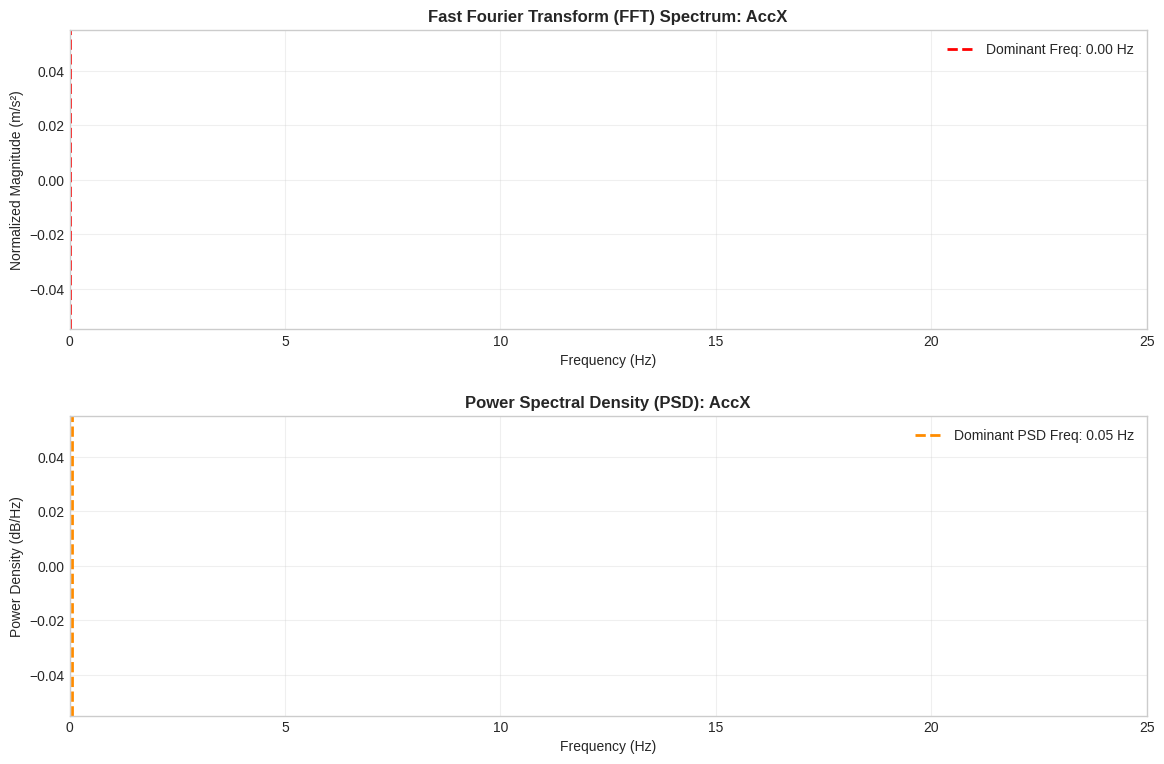

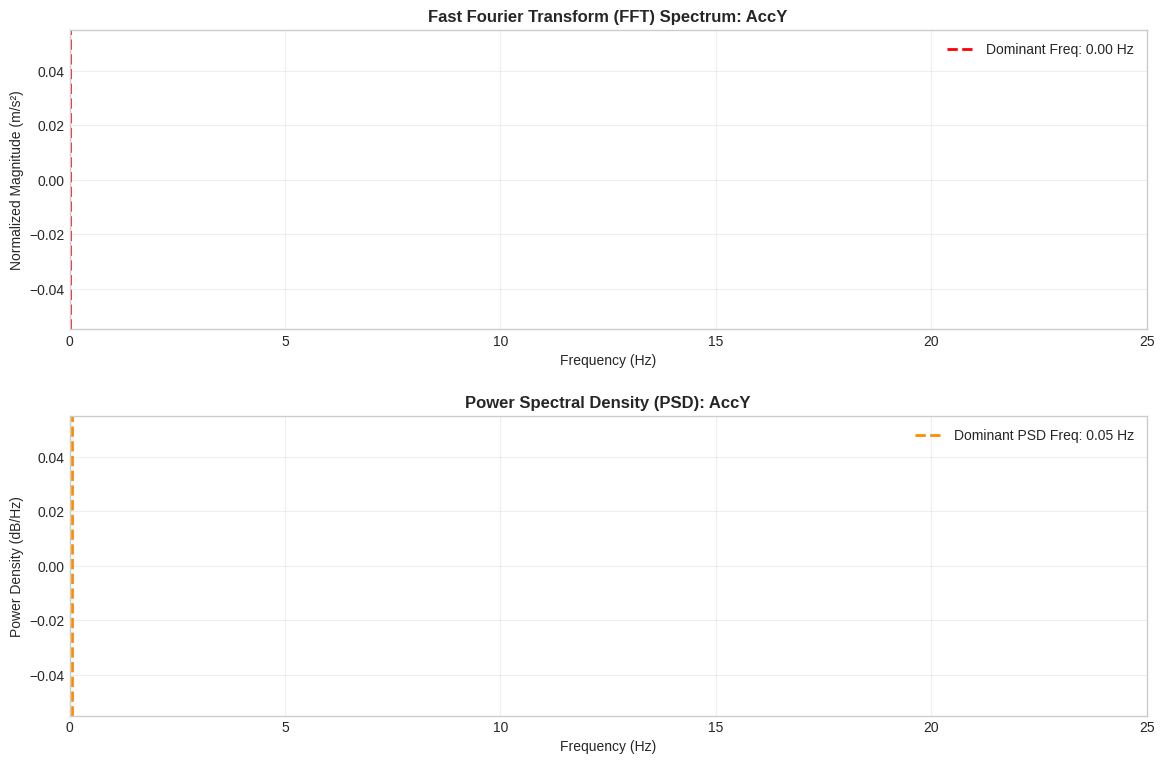

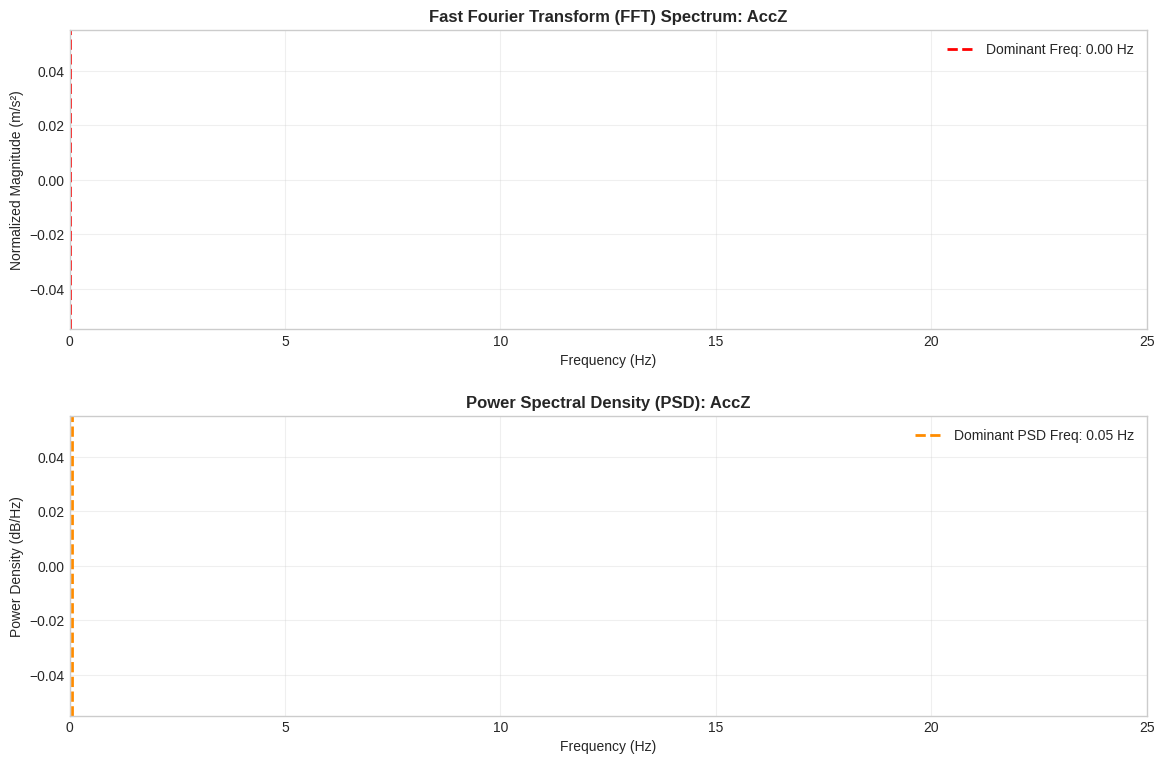

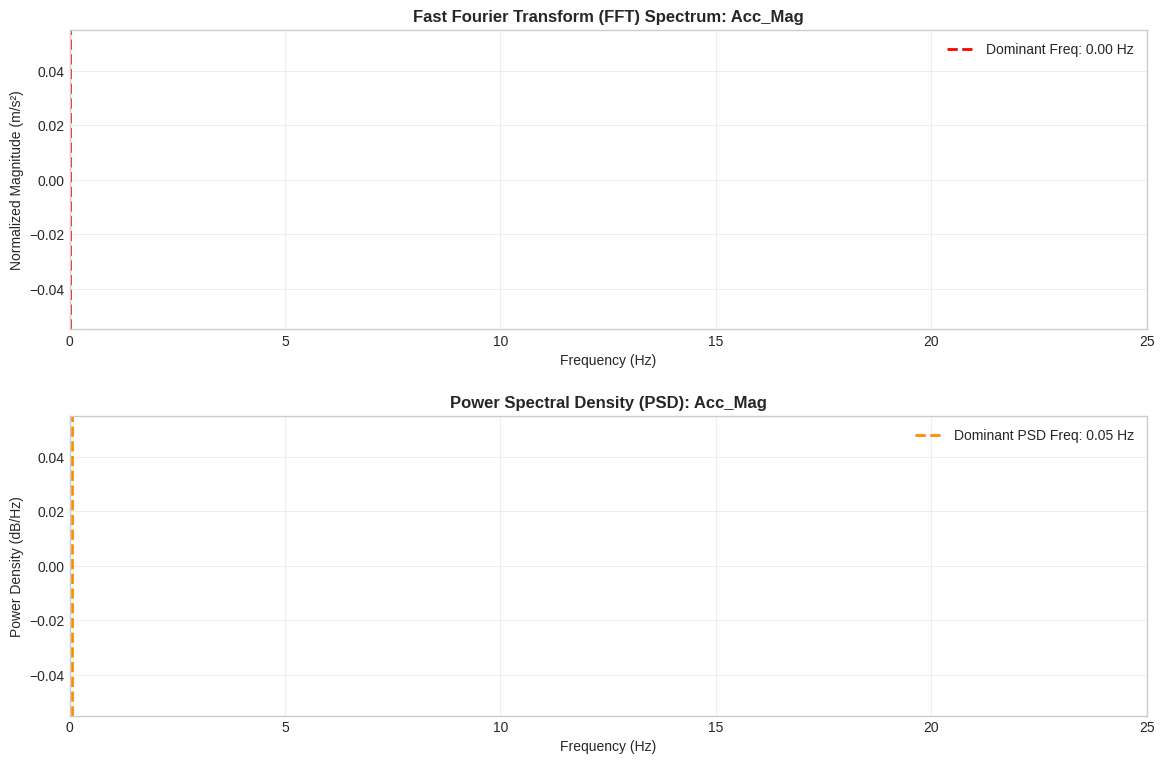

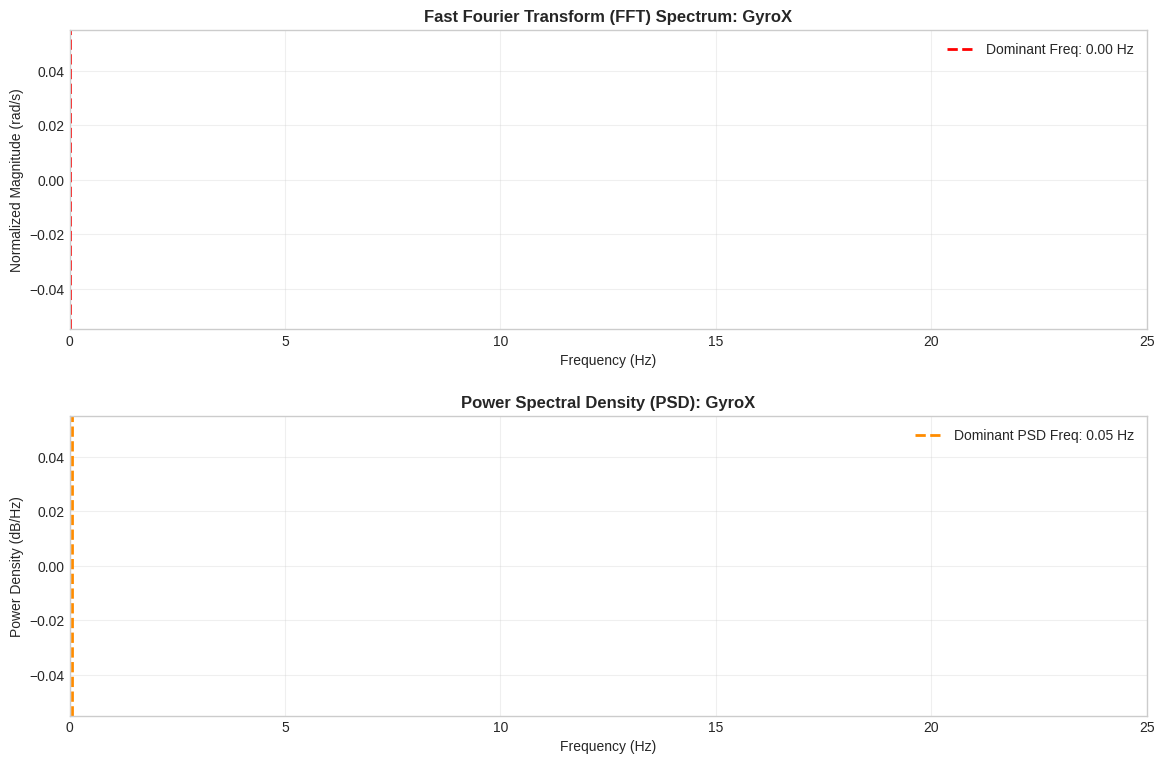

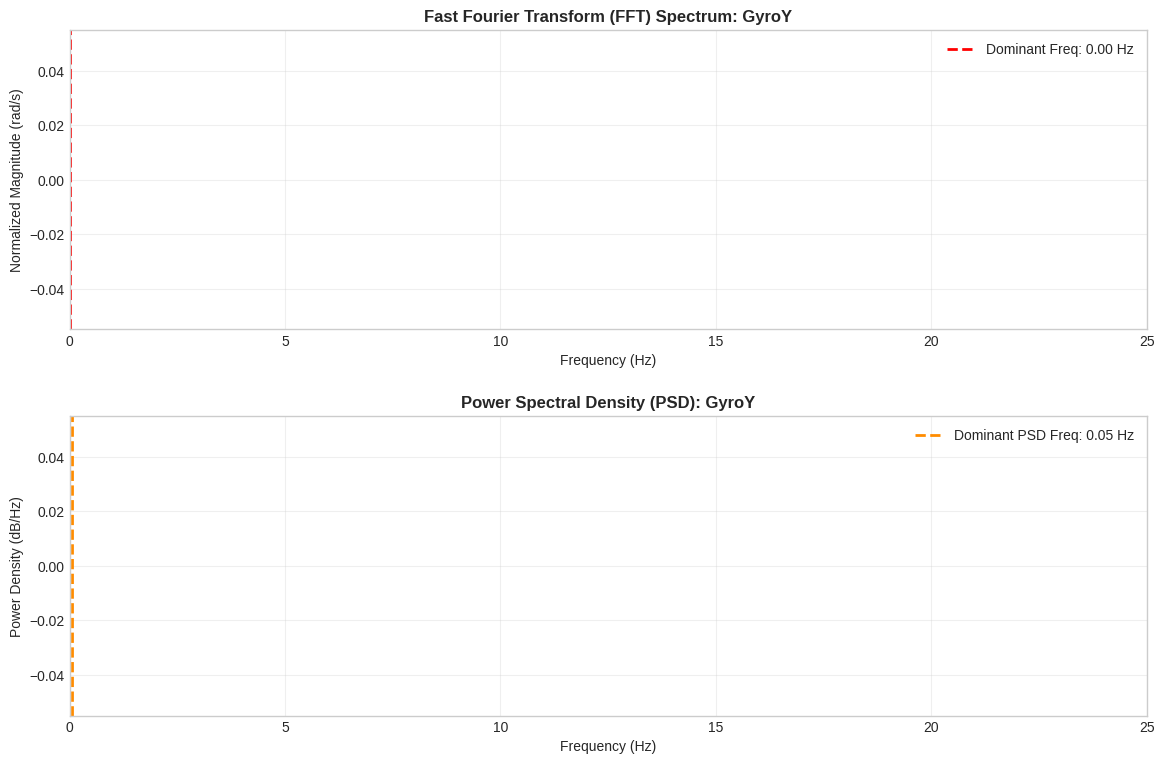

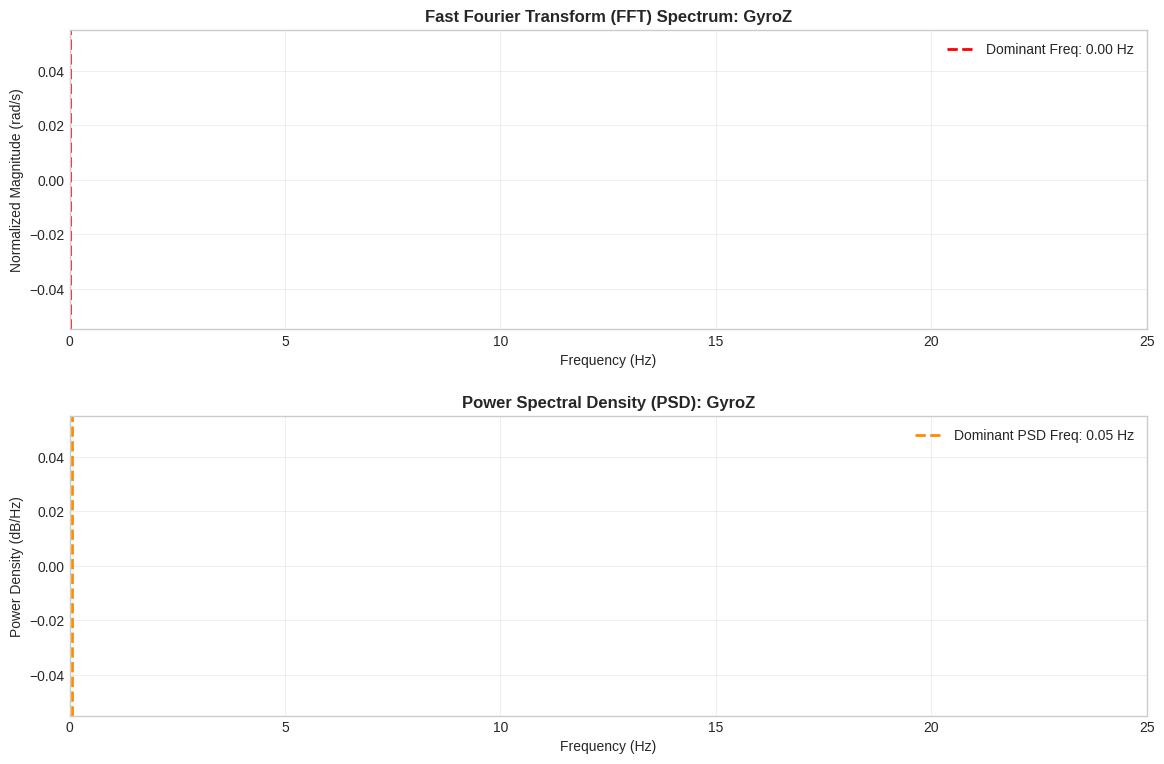

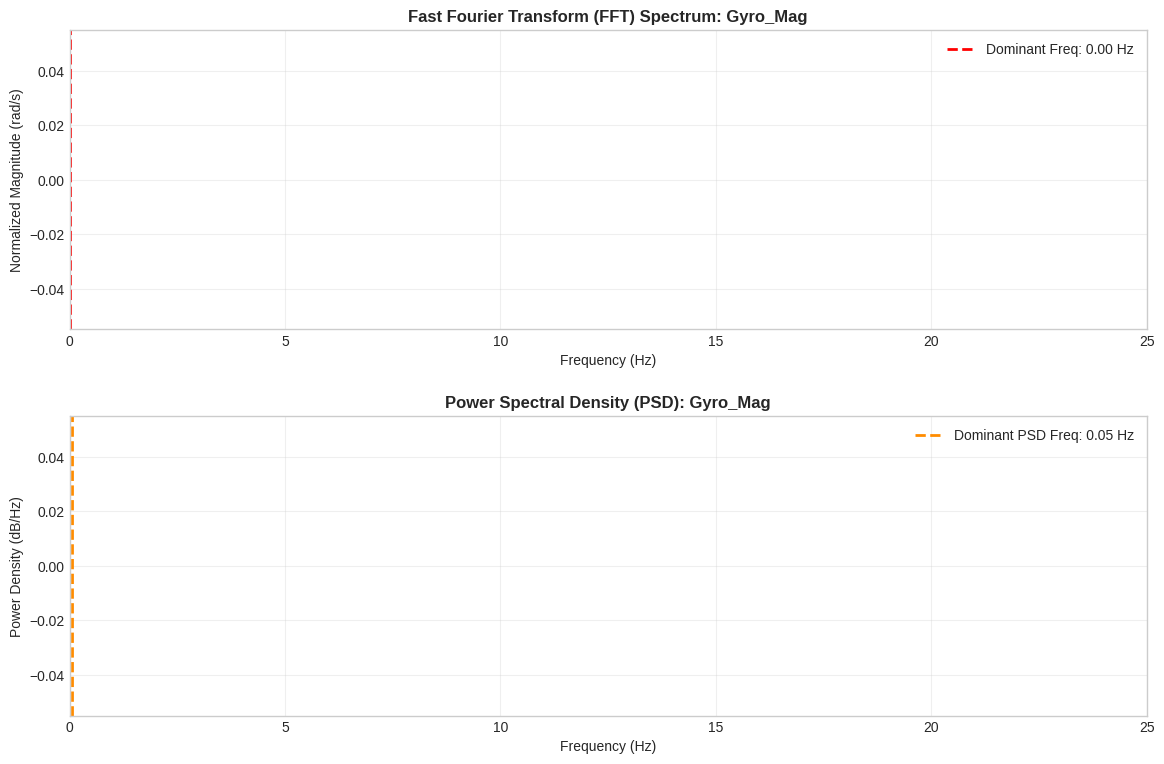

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fft_accx(df, fs):
    """
    Plot FFT spectrum for AccX only.
    df : pandas DataFrame containing 'AccX'
    fs : sampling frequency (Hz)
    """
    # Extract AccX
    data = df['AccX'].values
    n = len(data)

    # FFT
    freqs = np.fft.rfftfreq(n, d=1/fs)
    mags = np.abs(np.fft.rfft(data))

    # Normalize for visibility
    if np.max(mags) > 0:
        mags = mags / np.max(mags)

    # Find dominant frequency
    dominant_idx = np.argmax(mags[1:]) + 1
    dominant_freq = freqs[dominant_idx]

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(freqs, mags, color='royalblue')
    plt.axvline(dominant_freq, color='red', linestyle='--',
                label=f'Dominant Freq: {dominant_freq:.2f} Hz')
    plt.title("FFT Spectrum: AccX")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Normalized Magnitude")
    plt.legend()
    plt.grid(True)
    plt.show()
analyzer.plot_frequency_analysis()